<a href="https://colab.research.google.com/github/Lighter01/Sound-Processing/blob/main/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/itmo-mbss-lab/sr_labs_book

Cloning into 'sr_labs_book'...
remote: Enumerating objects: 395, done.
remote: Counting objects: 100% (139/139), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 395 (delta 89), reused 38 (delta 36), pack-reused 256 (from 1)
Receiving objects: 100% (395/395), 6.34 MiB | 16.06 MiB/s, done.
Resolving deltas: 100% (176/176), done.


In [ ]:
import os
import sys

sys.path.insert(0, os.path.realpath('/content/sr_labs_book'))

from common.dataprep import download_dataset, extract_dataset

from math import sqrt, pi
from scipy.fftpack import dct
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import hist, plot, show, grid, title, \
xlabel, ylabel, legend, axis, imshow
from mpl_toolkits.axes_grid1 import make_axes_locatable
from skimage.morphology import opening, closing
from torchaudio.transforms import Resample
from multiprocessing import Pool
import torchaudio
from lab1.exercises_blank import split_meta_line, preemphasis, \
framing, power_spectrum
from lab1.exercises_blank import compute_fbank_filters, \
compute_fbanks_features, compute_mfcc, mvn_floating

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
extract_dataset(save_path='/content/sr_labs_book/data/voxceleb1_test', fname='/content/drive/MyDrive/audio/vox1_test_wav (1).zip')

Extracting of /content/drive/MyDrive/audio/vox1_test_wav (1).zip is successful.


In [ ]:
def split_meta_line(line, delimiter=' '):
    """
    :param line: lines of metadata
    :param delimiter: delimeter
    :return: speaker_id: speaker IDs: gender: gender: file_path: path to file
    """
    arr = line.split(delimiter)
    speaker_id, gender, file_path = arr

    return speaker_id, gender, file_path

def preemphasis(signal, pre_emphasis=0.97):
    #Here you need to preemphasis input signal with pre_emphasis coeffitient

    """
    :param signal: input signal
    :param pre_emphasis: preemphasis coeffitient
    :return: emphasized_signal: signal after pre-emphasis procedure
    """

    emphasized_signal = [signal[0]]
    for i in range(1, len(signal)):
        y = signal[i] - pre_emphasis * signal[i-1]
        emphasized_signal.append(y)
    return emphasized_signal

def make_specgrams_plot(signal, emphasized_signal, sample_rate):
    """
    :signal: existed signal
    :emphasized_signal delimiter: transformed signal
    :return: specgrams
    """
    plt.figure(figsize=(15, 10))
    plt.subplots_adjust(wspace=0, hspace=0.5)
    plot_a = plt.subplot(311)
    plot_a.plot(signal)
    plot_a.set_xlabel('n')
    plot_a.set_ylabel('x(n)')
    plot_a.title.set_text('Original signal')
    plot_a.grid()
    plot_b = plt.subplot(312)
    plot_b.specgram(signal, NFFT=1024, Fs=sample_rate, noverlap=900)
    plot_b.set_xlabel('Time, s')
    plot_b.set_ylabel('Frequency, Hz')
    plot_b.title.set_text('Spectrogram of original signal')
    plot_c = plt.subplot(313)
    plot_c.specgram(emphasized_signal, NFFT=1024, Fs=sample_rate,
    noverlap=900)
    plot_c.set_xlabel('Time, s')
    plot_c.set_ylabel('Frequency, Hz')
    plot_c.title.set_text('Spectrogram of emphasized signal')
    plt.show()


def framing(emphasized_signal, sample_rate=16000, frame_size=0.025, frame_stride=0.01):

    """
    :param emphasized_signal: signal after pre-emphasis procedure
    :param sample_rate: signal sampling rate
    :param frame_size: sliding window size
    :param frame_stride: step
    :return: frames: output matrix [nframes x sample_rate*frame_size]
    """

    frame_length, frame_step = frame_size * sample_rate, frame_stride * sample_rate # convert from seconds to samples
    signal_length = len(emphasized_signal)
    frame_length = int(round(frame_length))
    frame_step = int(round(frame_step))
    num_frames = int(np.ceil(float(np.abs(signal_length - frame_length)) / frame_step)) # make sure that we have at least 1 frame

    pad_signal_length = num_frames * frame_step + frame_length
    z = np.zeros((pad_signal_length - signal_length))
    pad_signal = np.append(emphasized_signal, z) # pad Signal to make sure that all frames have equal number of samples without
                                                 # truncating any samples from the original signal

    indices = np.arange(frame_length) + np.arange(num_frames)[:, None] * frame_step
    frames = pad_signal[indices]
    hamming_window = np.hamming(frame_length)
    frames = frames * hamming_window

    return frames

def power_spectrum(frames, NFFT=512):
    """
    :param frames: framed signal
    :param NFFT: number of fft bins
    :return: pow_frames: framed signal power spectrum
    """

    mag_frames = np.absolute(np.fft.rfft(frames, NFFT))

    pow_frames = (np.abs(mag_frames)**2)/mag_frames.shape[1]

    return pow_frames

def compute_fbank_filters(nfilt=40, sample_rate=16000, NFFT=512):
    """
    :param nfilt: number of filters
    :param sample_rate: signal sampling rate
    :param NFFT: number of fft bins in power spectrum
    :return: fbank [nfilt x (NFFT/2+1)]
    """

    low_freq_mel = 0
    high_freq = sample_rate / 2
    high_freq_mel = 1127 * np.log(1 + high_freq/700) # high_freq -> high_freq_mel
    mel_points = np.linspace(low_freq_mel, high_freq_mel, nfilt + 2) # equally spaced in mel scale
    hz_points = 700 * (np.exp(mel_points/1127) - 1) # mel_points -> hz_points

    bin = np.floor((NFFT + 1) * hz_points / sample_rate)

    fbank = np.zeros((nfilt, int(np.floor(NFFT / 2 + 1))))
    for m in range(1, nfilt + 1):
        f_m_minus = int(bin[m - 1]) # left
        f_m = int(bin[m])           # center
        f_m_plus = int(bin[m + 1])  # right

        for k in range(f_m_minus, f_m):
            fbank[m - 1, k] = (k - bin[m - 1]) / (bin[m] - bin[m - 1])
        for k in range(f_m, f_m_plus):
            fbank[m - 1, k] = (bin[m + 1] - k) / (bin[m + 1] - bin[m])

    return fbank

def compute_fbanks_features(pow_frames, fbank):
    """
    :param pow_frames: framed signal power spectrum, matrix [nframes x sample_rate*frame_size]
    :param fbank: matrix of the fbank filters [nfilt x (NFFT/2+1)] where NFFT: number of fft bins in power spectrum
    :return: filter_banks_features: log mel FB energies matrix [nframes x nfilt]
    """
    filter_banks_features = pow_frames @ fbank.T
    filter_banks_features = np.where(filter_banks_features == 0, np.finfo(float).eps,
                                     filter_banks_features) # numerical stability
    filter_banks_features = np.log(filter_banks_features)

    return filter_banks_features

def compute_mfcc(filter_banks_features, num_ceps=20):
    # Here you need to compute MFCCs features using precomputed log mel FB energies matrix

    """
    :param filter_banks_features: log mel FB energies matrix [nframes x nfilt]
    :param num_ceps: number of cepstral components for MFCCs
    :return: mfcc: mel-frequency cepstral coefficients (MFCCs)
    """
    mfcc = dct(filter_banks_features, type=2, axis=1, norm='ortho')
    mfcc = mfcc[:, :num_ceps]

    return mfcc


def mvn_floating(features, LC, RC, unbiased=False):
    """
    :param features: features matrix [nframes x nfeats]
    :param LC: the number of frames to the left defining the floating
    :param RC: the number of frames to the right defining the floating
    :param unbiased: biased or unbiased estimation of normalising sigma
    :return: normalised_features: normalised features matrix [nframes x nfeats]
    """

    nframes, dim = features.shape
    LC = min(LC, nframes - 1)
    RC = min(RC, nframes - 1)
    n = (np.r_[np.arange(RC + 1, nframes), np.ones(RC + 1) * nframes] - np.r_[np.zeros(LC), np.arange(nframes - LC)])[:,
        np.newaxis]
    f = np.cumsum(features, 0)
    s = np.cumsum(features ** 2, 0)
    f = (np.r_[f[RC:], np.repeat(f[[-1]], RC, axis=0)] - np.r_[np.zeros((LC + 1, dim)), f[:-LC - 1]]) / n
    s = (np.r_[s[RC:], np.repeat(s[[-1]], RC, axis=0)] - np.r_[np.zeros((LC + 1, dim)), s[:-LC - 1]]
         ) / (n - 1 if unbiased else n) - f ** 2 * (n / (n - 1) if unbiased else 1)

    normalised_features = (features - f) / np.sqrt(s)
    normalised_features[s == 0] = 0

    return normalised_features


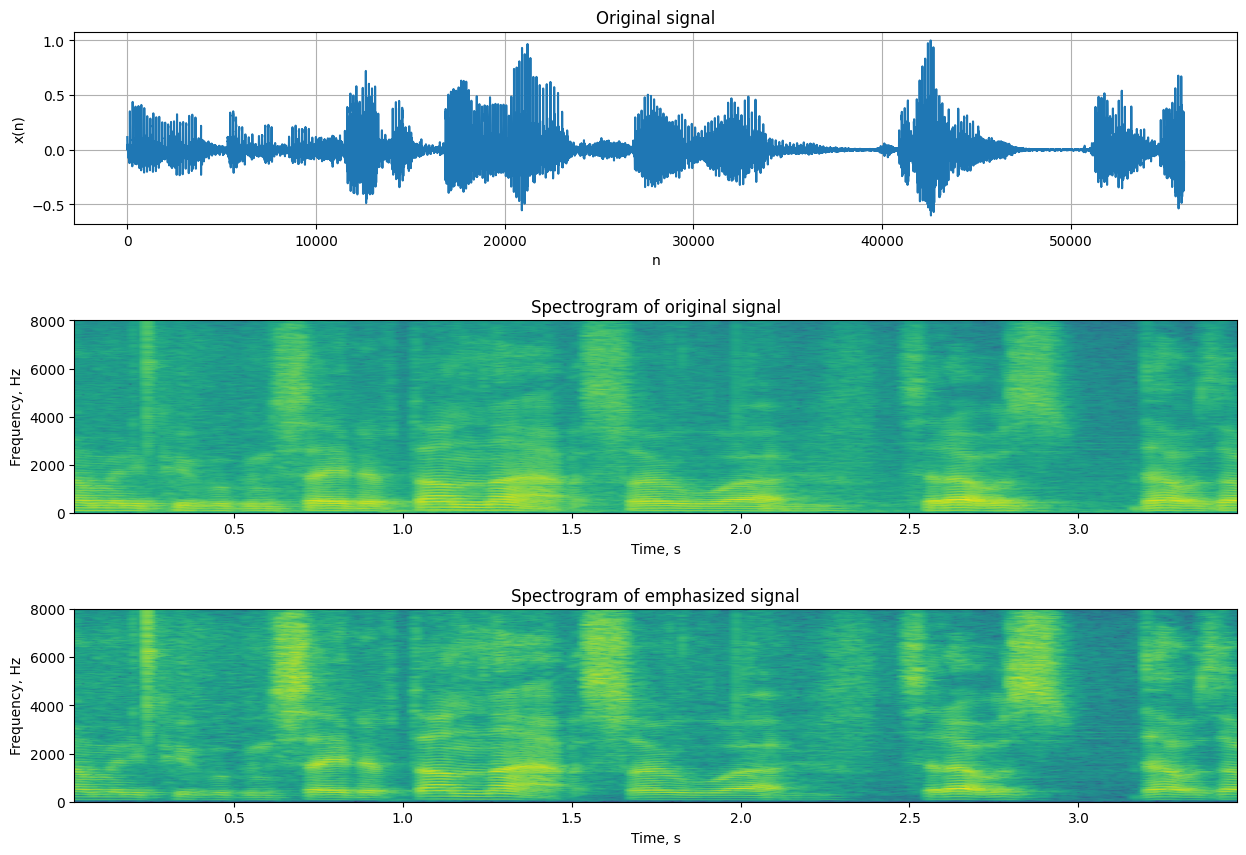

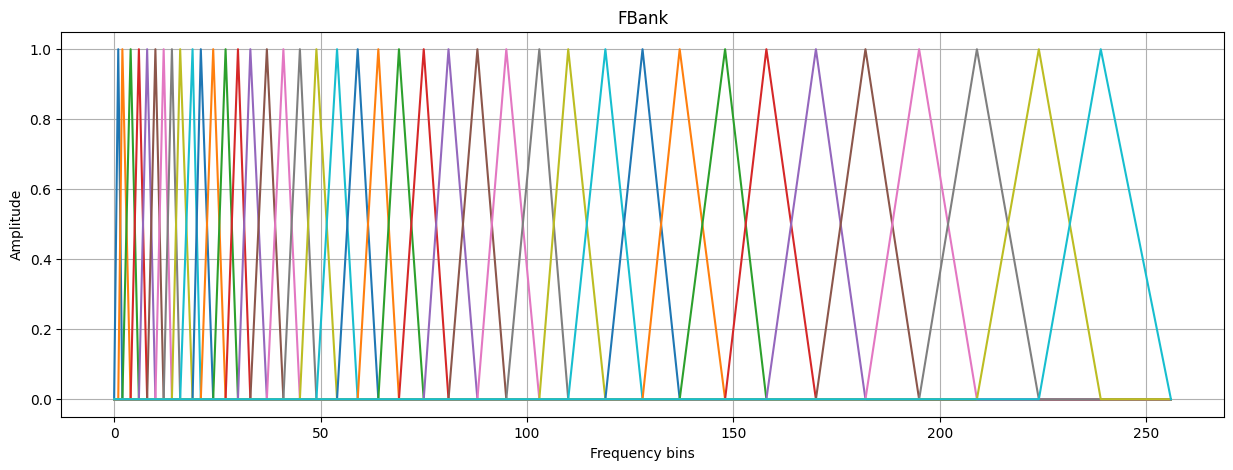

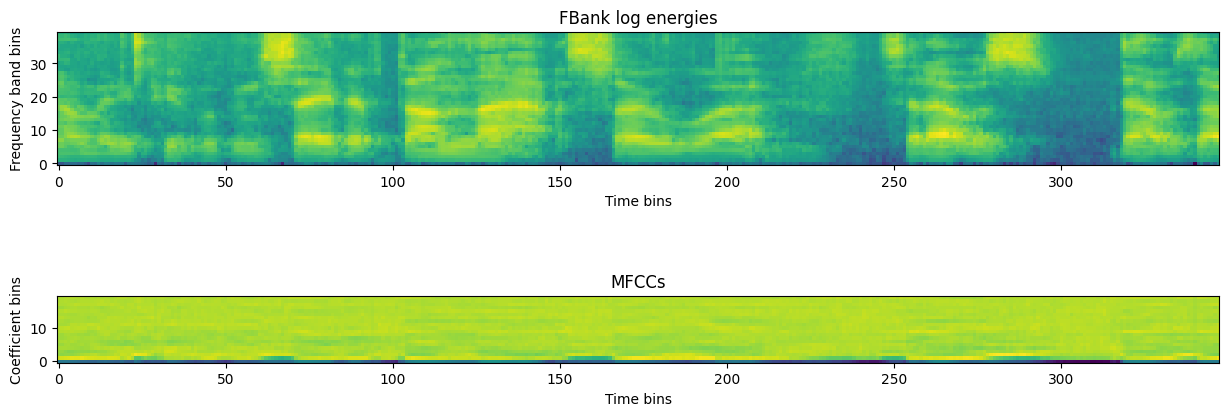

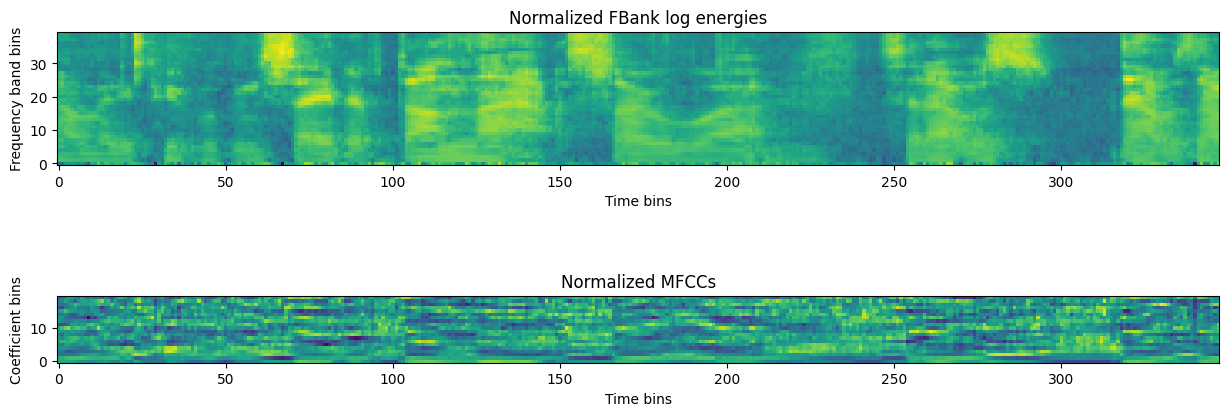

In [ ]:
path_to_meta = '/content/sr_labs_book/lab1/metadata/meta.txt'
p = Pool(1)
with open(path_to_meta, 'r') as f:
    list_lines = f.readlines()
    speaker_ids, genders, paths = zip(*p.map(split_meta_line, list_lines[1:]))
    path_to_wav = f'/content/sr_labs_book{paths[0][2:-1]}'
    # Load signal
    signal, sample_rate = torchaudio.load(path_to_wav)
    signal = signal.numpy().squeeze(axis=0)
    signal = signal/np.abs(signal).max()
    signal = signal[0:int(3.5 * sample_rate)]

    emphasized_signal = preemphasis(signal) # emphasized signal
    make_specgrams_plot(signal, emphasized_signal, sample_rate)

    frames = framing(emphasized_signal)
    pow_frames = power_spectrum(frames)
    fbank = compute_fbank_filters(nfilt=40, sample_rate=16000, NFFT=512)
    plt.figure(figsize=(15, 5))
    plot_a = plt.subplot()
    plt.subplots_adjust(wspace=0, hspace=1)
    nfilt = fbank.shape[0]
    for k in range(nfilt):
        plot_a.plot(fbank[k,:])
    plot_a.set_xlabel('Frequency bins')
    plot_a.set_ylabel('Amplitude')
    plot_a.title.set_text('FBank')
    plot_a.grid()
    plt.show()
    filter_banks_features = compute_fbanks_features(pow_frames, fbank)
    # Mel frequency cepstral coefficients
    mfcc = compute_mfcc(filter_banks_features, num_ceps=20)
    plt.figure(figsize=(15, 5))
    plt.subplots_adjust(wspace=0, hspace=0.5)
    plot_a = plt.subplot(211)
    plot_a.imshow(filter_banks_features.T, origin='lower')
    plot_a.set_xlabel('Time bins')
    plot_a.set_ylabel('Frequency band bins')
    plot_a.title.set_text('FBank log energies')
    plot_b = plt.subplot(212)
    im = plot_b.imshow(mfcc.T, origin='lower')
    plot_b.set_xlabel('Time bins')
    plot_b.set_ylabel('Coefficient bins')
    plot_b.title.set_text('MFCCs')
    plt.show()
    filter_banks_features_mvn = \
    mvn_floating(filter_banks_features, 150, 150)
    # Normalized and scaled mel frequency cepstral coefficients
    mfcc_cmvn = mvn_floating(mfcc, 150, 150)
    fig = plt.figure(figsize=(15, 5))
    plt.subplots_adjust(wspace=0, hspace=0.5)
    plot_b = plt.subplot(211)
    im_b = plot_b.imshow(filter_banks_features_mvn.T,
    origin='lower')
    plot_b.set_xlabel('Time bins')
    plot_b.set_ylabel('Frequency band bins')
    plot_b.title.set_text('Normalized FBank log energies')
    plot_с = plt.subplot(212)
    im_c = plot_с.imshow(mfcc_cmvn.T, origin='lower')
    plot_с.set_xlabel('Time bins')
    plot_с.set_ylabel('Coefficient bins')
    plot_с.title.set_text('Normalized MFCCs')
    plt.show()




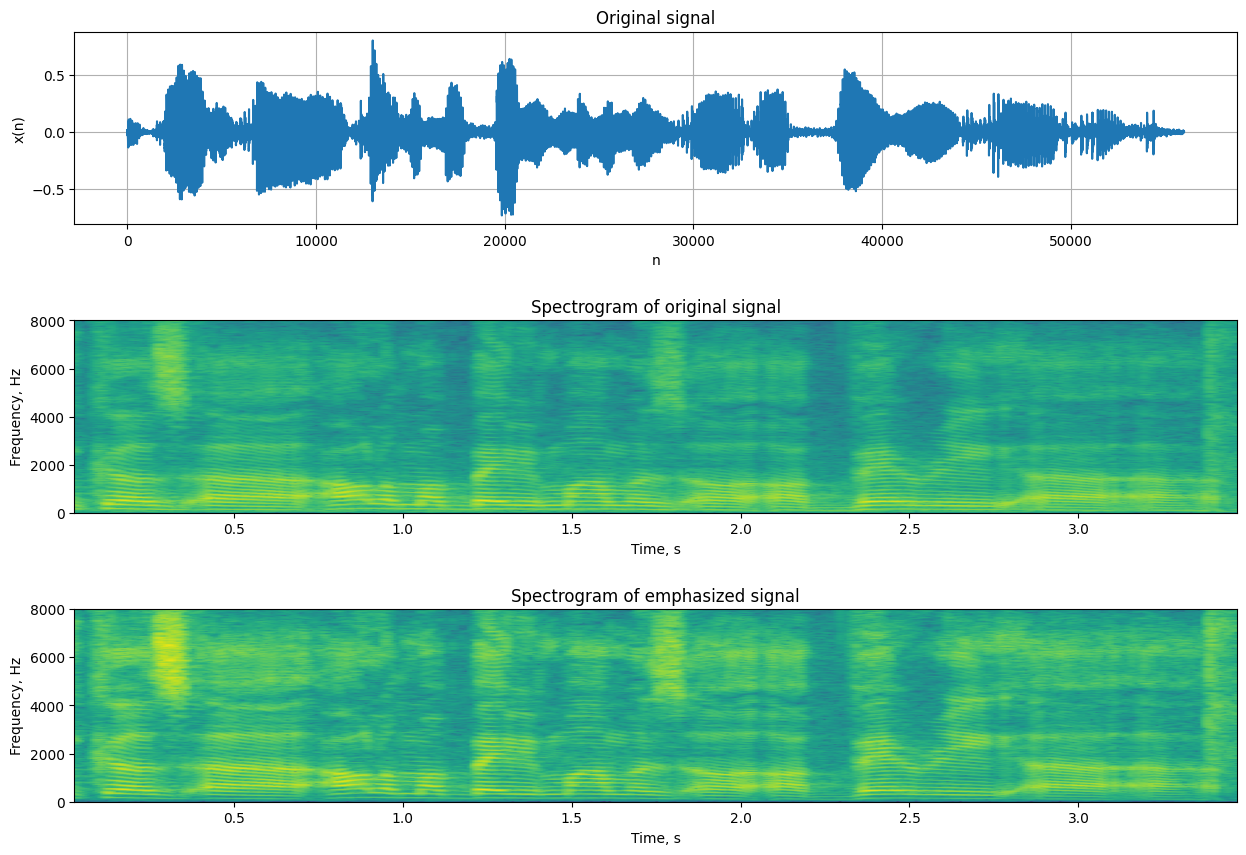

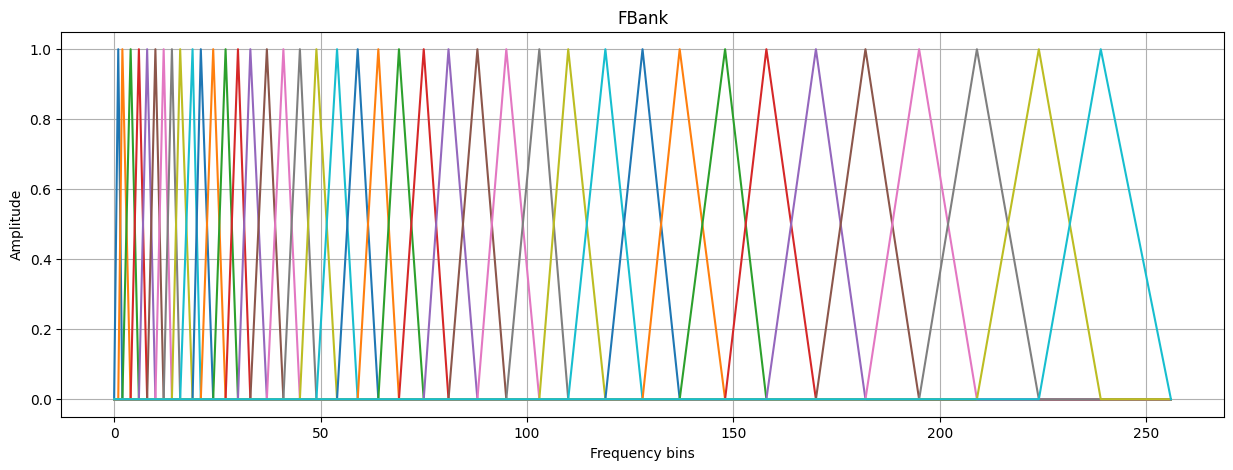

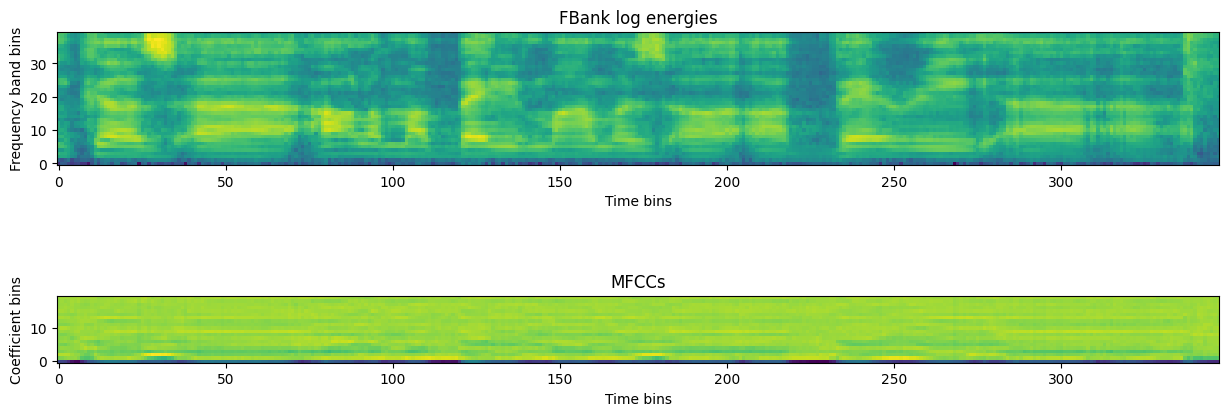

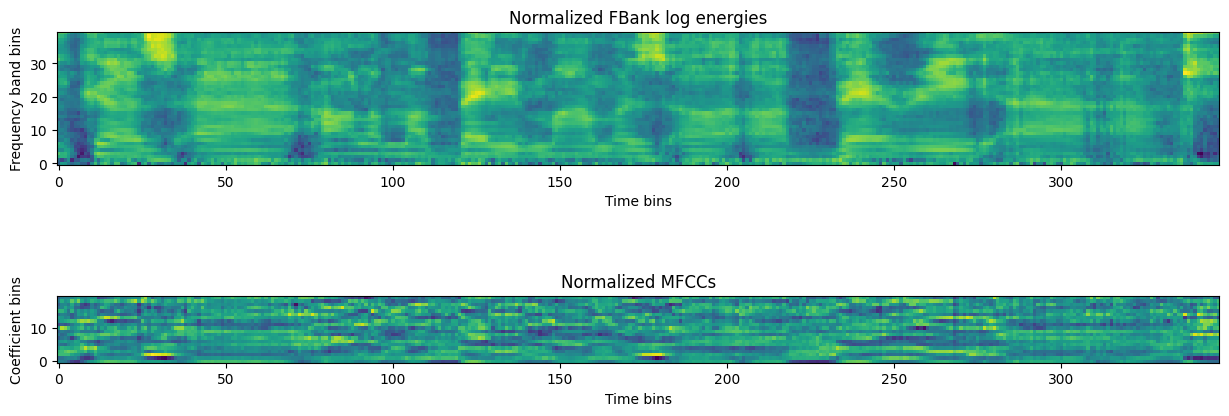

In [ ]:
path_to_meta = '/content/sr_labs_book/lab1/metadata/meta.txt'
p = Pool(1)
with open(path_to_meta, 'r') as f:
    list_lines = f.readlines()
    speaker_ids, genders, paths = zip(*p.map(split_meta_line, list_lines[1:]))
    path_to_wav = f'/content/sr_labs_book{paths[1][2:-1]}'
    # Load signal
    signal, sample_rate = torchaudio.load(path_to_wav)
    signal = signal.numpy().squeeze(axis=0)
    signal = signal/np.abs(signal).max()
    signal = signal[0:int(3.5 * sample_rate)]

    emphasized_signal = preemphasis(signal) # emphasized signal
    make_specgrams_plot(signal, emphasized_signal, sample_rate)

    frames = framing(emphasized_signal)
    pow_frames = power_spectrum(frames)
    fbank = compute_fbank_filters(nfilt=40, sample_rate=16000, NFFT=512)
    plt.figure(figsize=(15, 5))
    plot_a = plt.subplot()
    plt.subplots_adjust(wspace=0, hspace=1)
    nfilt = fbank.shape[0]
    for k in range(nfilt):
        plot_a.plot(fbank[k,:])
    plot_a.set_xlabel('Frequency bins')
    plot_a.set_ylabel('Amplitude')
    plot_a.title.set_text('FBank')
    plot_a.grid()
    plt.show()
    filter_banks_features = compute_fbanks_features(pow_frames, fbank)
    # Mel frequency cepstral coefficients
    mfcc = compute_mfcc(filter_banks_features, num_ceps=20)
    plt.figure(figsize=(15, 5))
    plt.subplots_adjust(wspace=0, hspace=0.5)
    plot_a = plt.subplot(211)
    plot_a.imshow(filter_banks_features.T, origin='lower')
    plot_a.set_xlabel('Time bins')
    plot_a.set_ylabel('Frequency band bins')
    plot_a.title.set_text('FBank log energies')
    plot_b = plt.subplot(212)
    im = plot_b.imshow(mfcc.T, origin='lower')
    plot_b.set_xlabel('Time bins')
    plot_b.set_ylabel('Coefficient bins')
    plot_b.title.set_text('MFCCs')
    plt.show()
    filter_banks_features_mvn = \
    mvn_floating(filter_banks_features, 150, 150)
    # Normalized and scaled mel frequency cepstral coefficients
    mfcc_cmvn = mvn_floating(mfcc, 150, 150)
    fig = plt.figure(figsize=(15, 5))
    plt.subplots_adjust(wspace=0, hspace=0.5)
    plot_b = plt.subplot(211)
    im_b = plot_b.imshow(filter_banks_features_mvn.T,
    origin='lower')
    plot_b.set_xlabel('Time bins')
    plot_b.set_ylabel('Frequency band bins')
    plot_b.title.set_text('Normalized FBank log energies')
    plot_с = plt.subplot(212)
    im_c = plot_с.imshow(mfcc_cmvn.T, origin='lower')
    plot_с.set_xlabel('Time bins')
    plot_с.set_ylabel('Coefficient bins')
    plot_с.title.set_text('Normalized MFCCs')
    plt.show()




(18908, 40)
(18604, 40)
(18908, 20)
(18604, 20)


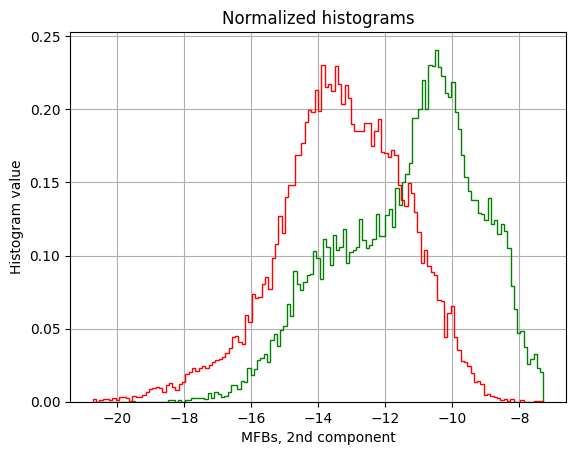

In [ ]:
fbank = compute_fbank_filters(nfilt=40, sample_rate=16000, NFFT=512)

def compute_feats(signal):
  # Function to compute log mel-filter bank energies and
  # mel frequency cepstral coefficients

  emphasized_signal = preemphasis(signal)
  frames = framing(emphasized_signal)
  pow_frames = power_spectrum(frames)
  filter_banks_features = \
  compute_fbanks_features(pow_frames, fbank)
  mfcc = compute_mfcc(filter_banks_features, num_ceps=20)

  return filter_banks_features, mfcc
male_fb_features = []
female_fb_features = []
male_mfcc_features = []
female_mfcc_features = []
for (path_to_wav, gender) in zip(paths, genders):
  # Load signal
  path_to_wav = f'/content/sr_labs_book{path_to_wav[2:-1]}'
  signal, sample_rate = torchaudio.load(path_to_wav)
  signal = signal.numpy().squeeze(axis=0)
  signal = signal/np.abs(signal).max()

  # Processing
  filter_banks_mvn, mfcc_cmvn = compute_feats(signal)
  if gender == 'm':
    male_fb_features.append(filter_banks_mvn)
    male_mfcc_features.append(mfcc_cmvn)

  else:
    female_fb_features.append(filter_banks_mvn)
    female_mfcc_features.append(mfcc_cmvn)
male_fb_features = np.concatenate(male_fb_features)
print(male_fb_features.shape)
female_fb_features = np.concatenate(female_fb_features)
print(female_fb_features.shape)
male_mfcc_features = np.concatenate(male_mfcc_features)
print(male_mfcc_features.shape)
female_mfcc_features = np.concatenate(female_mfcc_features)
print(female_mfcc_features.shape)
comp_number = 1
coeff1_male = male_fb_features[:, comp_number]
coeff1_female = female_fb_features[:, comp_number]
min_coeff1 = min(coeff1_male.min(), coeff1_female.min())
max_coeff1 = min(coeff1_male.max(), coeff1_female.max())
hist(coeff1_male, \
 int(sqrt(len(coeff1_male))), \
 histtype='step', \
 color='green', \
 range=(min_coeff1, max_coeff1), \
 density=1)
hist(coeff1_female, \
 int(sqrt(len(coeff1_female))), \
 histtype='step', \
 color='red', \
 range=(min_coeff1, max_coeff1), \
 density=1)
xlabel('MFBs, 2nd component'); ylabel('Histogram value')
title('Normalized histograms'); grid(); show()